<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/V01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, peak_widths
import time

try:
    from google.colab import files
except ImportError:
    files = None


class DSPAnalysis:
    def __init__(self, gain_dBi=0, f_start=0, f_stop=np.inf):
        """
        Automated DSP analysis pipeline: load, convert, correct, estimate noise floor, and detect peaks.
        """
        self.gain_dBi = float(gain_dBi)
        self.f_start = float(f_start)
        self.f_stop = float(f_stop)
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.detected_peaks_ = None

        self._load_csv()
        self._convert_to_dBm_per_Hz()
        self._apply_gain_correction()
        self._estimate_noise_floor()
        self._detect_peaks_threshold(delta_dB=0.5)

    # =====================================================================
    # 1. FAST CSV LOADING
    # =====================================================================
    def _load_csv(self):
        """Load and clean CSV with expected columns."""
        if files:
            uploaded = files.upload()
            path = next(iter(uploaded))
        else:
            path = input("Enter CSV file path: ").strip()

        df = pd.read_csv(path)

        rename_map = {"frequency (Hz)": "freq_Hz", "PSD (V^2/Hz)": "psd_V2Hz"}
        df = df.rename(columns=rename_map)

        if not {"freq_Hz", "psd_V2Hz"}.issubset(df.columns):
            raise ValueError("CSV must contain 'frequency (Hz)' and 'PSD (V^2/Hz)' columns.")

        df = df.sort_values("freq_Hz", kind="mergesort").dropna(subset=["freq_Hz", "psd_V2Hz"])
        self.df = df.reset_index(drop=True)

    # =====================================================================
    # 2. VECTORIZED PSD CONVERSION
    # =====================================================================
    def _convert_to_dBm_per_Hz(self):
        """Convert PSD from V²/Hz to dBm/Hz (fully vectorized)."""
        psd_linear = self.df["psd_V2Hz"].to_numpy(dtype=np.float64)
        psd_WHz = np.maximum(psd_linear / 50.0, 1e-18)  # Avoid log(0)
        self.df["psd_dBmHz"] = 10 * np.log10(psd_WHz) + 30.0

    # =====================================================================
    # 3. GAIN CORRECTION (FAST MASKED SUBTRACTION)
    # =====================================================================
    def _apply_gain_correction(self):
        if self.gain_dBi != 0:
            f = self.df["freq_Hz"].to_numpy()
            mask = (f >= self.f_start) & (f <= self.f_stop)
            psd = self.df["psd_dBmHz"].to_numpy(copy=True)
            psd[mask] -= self.gain_dBi
            self.df["psd_dBmHz"] = psd
            print(f"✅ Applied gain correction of {self.gain_dBi} dBi between "
                  f"{self.f_start/1e6:.2f}–{self.f_stop/1e6:.2f} MHz")
        else:
            print("ℹ️ No gain correction applied (gain_dBi = 0).")

    # =====================================================================
    # 4. NOISE FLOOR ESTIMATION (FAST HISTOGRAM-BASED)
    # =====================================================================
    def _estimate_noise_floor(self):
        psd_dBm = self.df["psd_dBmHz"].to_numpy(dtype=np.float64)
        hist, bin_edges = np.histogram(psd_dBm, bins=500)
        mode_center = (bin_edges[np.argmax(hist)] + bin_edges[np.argmax(hist) + 1]) / 2

        mask = np.abs(psd_dBm - mode_center) <= 3
        noise_floor = np.mean(psd_dBm[mask]) if np.any(mask) else mode_center
        self.noise_floor_dBmHz_ = float(noise_floor)

    # =====================================================================
    # 5. FAST PEAK DETECTION USING NUMPY THRESHOLDING
    # =====================================================================
    def _detect_peaks_threshold(self, delta_dB=0.5):
        psd_dBm = self.df["psd_dBmHz"].to_numpy(dtype=np.float64)
        freq = self.df["freq_Hz"].to_numpy(dtype=np.float64)
        threshold = self.noise_floor_dBmHz_ + delta_dB

        mask = psd_dBm > threshold
        if not np.any(mask):
            print("⚠️ No peaks detected above threshold.")
            self.detected_peaks_ = pd.DataFrame(columns=["f₀ (MHz)", "Amp (dBm/Hz)", "BW (Hz)"])
            return

        # Identify contiguous segments efficiently
        diff = np.diff(mask.astype(int))
        start_idx = np.flatnonzero(diff == 1) + 1
        end_idx = np.flatnonzero(diff == -1) + 1

        # Handle edge cases (segment at start or end)
        if mask[0]:
            start_idx = np.r_[0, start_idx]
        if mask[-1]:
            end_idx = np.r_[end_idx, len(mask)]

        peaks = []
        for s, e in zip(start_idx, end_idx):
            seg_psd = psd_dBm[s:e]
            seg_freq = freq[s:e]
            if seg_psd.size == 0:
                continue
            i_max = np.argmax(seg_psd)
            f0 = seg_freq[i_max]
            amp = seg_psd[i_max]
            bw = seg_freq[-1] - seg_freq[0]
            peaks.append((f0 / 1e6, amp, bw))

        self.detected_peaks_ = pd.DataFrame(peaks, columns=["f₀ (MHz)", "Amp (dBm/Hz)", "BW (Hz)"])

        if len(peaks):
            print(f"✅ {len(peaks)} peaks detected above {threshold:.2f} dBm/Hz")

    # =====================================================================
    # 6. PLOTTING UTILITIES
    # =====================================================================
    def plot_psd(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.title("PSD (dBm/Hz) vs Frequency")
        plt.xlabel("Frequency [MHz]")
        plt.ylabel("PSD [dBm/Hz]")
        plt.grid(True)
        plt.show()

    def plot_noise_floor(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.axhline(self.noise_floor_dBmHz_, color="red", ls="--",
                    label=f"Noise floor = {self.noise_floor_dBmHz_:.2f} dBm/Hz")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_detected_peaks(self):
        if self.detected_peaks_ is None or self.detected_peaks_.empty:
            print("⚠️ No peaks to plot.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df["freq_Hz"] / 1e6, self.df["psd_dBmHz"], lw=1)
        plt.scatter(self.detected_peaks_["f₀ (MHz)"], self.detected_peaks_["Amp (dBm/Hz)"],
                    color="red", s=30, label="Detected Peaks")
        plt.axhline(self.noise_floor_dBmHz_ + 0.5, color="green", ls="--",
                    label=f"Threshold = noise floor + 0.5 dB ({self.noise_floor_dBmHz_ + 0.5:.2f})")
        plt.legend()
        plt.grid(True)
        plt.show()


📁 File '/content/n0.csv' loaded successfully (4096 samples).
⏱️ CSV loaded in 0.009 s

Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
⏱️ Conversion to dBm/Hz done in 0.003 s

✅ Applied gain correction of 0.5 dBi between -12.00 MHz and 10.00 MHz.
⏱️ Gain correction applied in 0.002 s

📉 Estimated noise floor: -66.43 dBm/Hz
⏱️ Noise floor estimated in 0.001 s


🔍 Detected 42 peaks (>-65.93 dBm/Hz)

📡 Peaks and bandwidths:
──────────────────────────────────────────────
• f₀ = -9.390 MHz | A = -64.43 dBm/Hz | BW = 141.6 kHz
• f₀ = -8.726 MHz | A = -65.86 dBm/Hz | BW = 4.9 kHz
• f₀ = -8.638 MHz | A = -64.96 dBm/Hz | BW = 180.7 kHz
• f₀ = -8.301 MHz | A = -62.88 dBm/Hz | BW = 73.2 kHz
• f₀ = -7.681 MHz | A = -65.92 dBm/Hz | BW = 0.0 kHz
• f₀ = -7.393 MHz | A = -65.53 dBm/Hz | BW = 97.7 kHz
• f₀ = -6.626 MHz | A = -64.73 dBm/Hz | BW = 136.7 kHz
• f₀ = -6.318 MHz | A = -62.17 dBm/Hz | BW = 92.8 kHz
• f₀ = -5.718 MHz | A = -65.89 dBm/Hz | BW = 4.9 kHz
• f₀ = -

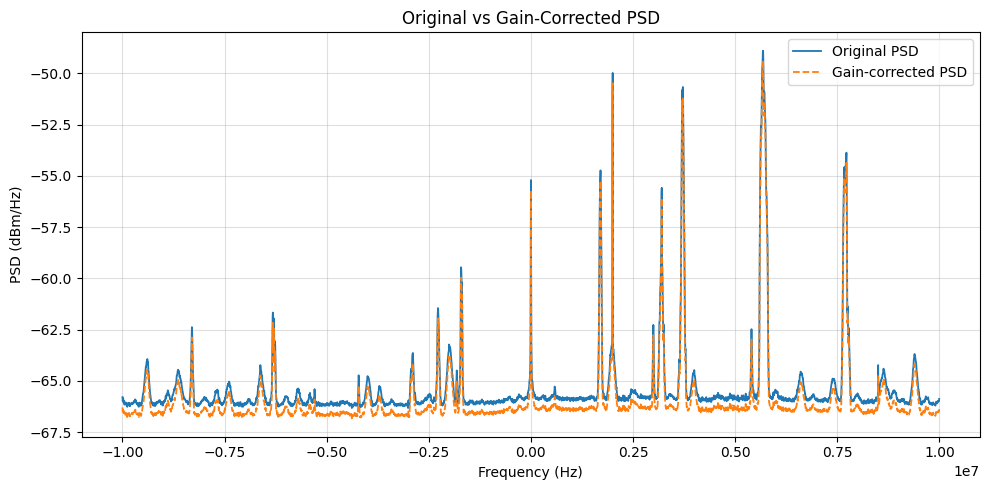

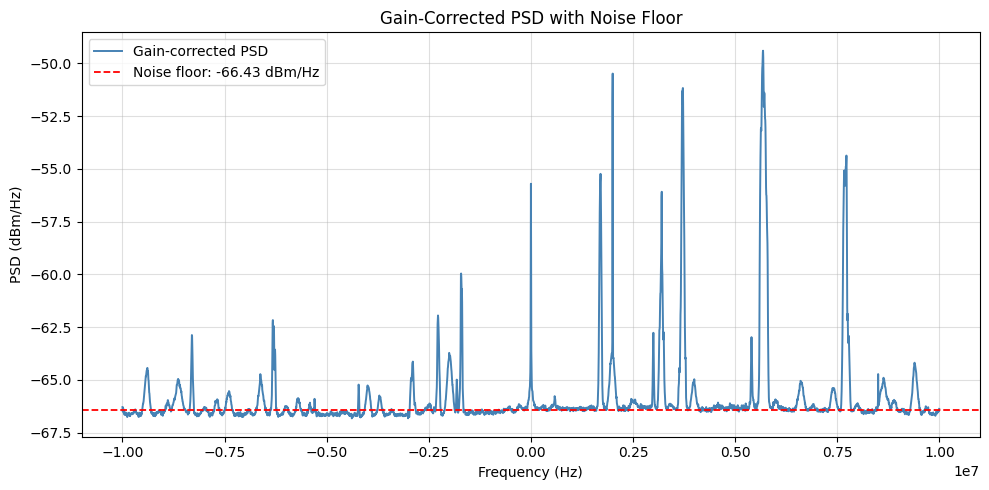

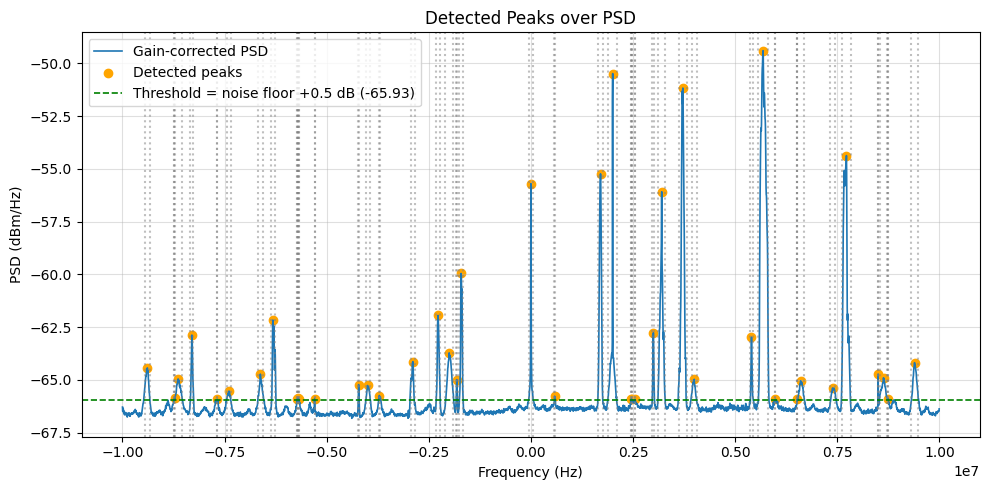

In [ ]:
t0=0

dsp = DigitalSignalProcessing(
    file_path='/content/n0.csv',
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)